> **Note:** **New to this architecture?** Walk through [`00_climb_to_compound.ipynb`](./00_climb_to_compound.ipynb) first — iterative-masking + position-likelihoods climb (runs in <60s with `PYAUTOFIT_TEST_MODE=1`).

---


# Compound-Lens Zoo — Overview

## Learning to Autolens / Examples / compound_lens_zoo

---

**Problem.** Hold the model and priors fixed. Throw five different lensing geometries at the same fit. Does the recovered (θ_E, γ′, e, source) correlate with the truths *across* the zoo?

**Mocks.** Five lenstronomy-generated compound mocks (mock_2 through mock_6) from `tutorials_DB_2025_09/`. All share the architecture (EPL + ExternalShear + EPL secondary + 2 Sersic sources + Sersic lens light) but vary z_l, z_s, γ′, ellipticity, and (for mocks 2 and 5) cosmology.

**Methodology.** One unified `PowerLaw + ExternalShear + Sersic-light` model with `n_live=200` Nautilus on every mock. Cosmology held at FlatLambdaCDM(70, 0.30) for ALL — including mocks 2 and 5 which were generated with different cosmologies (their offsets are part of what we're measuring, see Exercise 2 in README).

**This notebook.** Loads the truth files + the Cannon-pulled fit results for all five mocks and assembles a comparison table. The point is *not* that any one mock recovers truth perfectly — it's that the recovered values correlate with the truths in the way you'd expect from formal posterior errors, which is what generalisation looks like.

**Prerequisites.** `compound_lens` + `mge_to_physical` (Pattern E + lenstronomy → autolens conventions). Optionally Module 11 for the audit methodology.

In [1]:
import os, json
if os.environ.get("PYAUTOFIT_TEST_MODE"):
    raise RuntimeError(
        f"PYAUTOFIT_TEST_MODE={os.environ['PYAUTOFIT_TEST_MODE']!r} is set."
    )
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display
import autolens as al
%matplotlib inline
print(f"PyAutoLens: {al.__version__}")

PyAutoLens: 2026.4.13.6


## 1. Truths + results inventory

In [2]:
MOCKS_DIR = Path("mocks")
RESULTS_DIR = Path("results")
MOCK_INDICES = [2, 3, 4, 5, 6]

truths_per_mock = {}
results_per_mock = {}
for n in MOCK_INDICES:
    truths_per_mock[n] = json.loads((MOCKS_DIR / f"truths_mock_{n}.json").read_text())
    summary_path = RESULTS_DIR / f"mock_{n}" / "summary.json"
    if summary_path.exists():
        results_per_mock[n] = json.loads(summary_path.read_text())
    else:
        results_per_mock[n] = None

rows = []
for n in MOCK_INDICES:
    t = truths_per_mock[n]
    primary = t["kwargs_lens"][0]
    res = results_per_mock[n]
    rows.append([n,
                 t["redshifts"]["lens_primary"],
                 t["redshifts"]["source"],
                 primary["theta_E"], primary["gamma"],
                 t["cosmology"].get("Om"), t["cosmology"].get("w"),
                 "✓" if res is not None else "(pending)"])

header = ("mock", "z_l", "z_s", "truth θ_E", "truth γ′", "Ωₘ", "w", "result")
md = ["| " + " | ".join(header) + " |",
      "|" + "|".join(["---"] * len(header)) + "|"]
for r in rows:
    md.append("| " + " | ".join(str(c) for c in r) + " |")
display(Markdown("\n".join(md)))

| mock | z_l | z_s | truth θ_E | truth γ′ | Ωₘ | w | result |
|---|---|---|---|---|---|---|---|
| 2 | 0.3 | 1.7 | 1.87 | 1.95 | 0.25 | -0.9 | ✓ |
| 3 | 0.5 | 2 | 2 | 2.5 | 0.3 | -1 | ✓ |
| 4 | 0.4 | 1.3 | 1.6 | 1.9 | 0.3 | -1 | ✓ |
| 5 | 0.3 | 1.7 | 1.71 | 1.95 | 0.35 | -1.2 | ✓ |
| 6 | 0.24 | 2 | 1.88 | 2.25 | 0.3 | -1 | ✓ |

---

## 2. Recovered vs truth

For each mock, the recovered `theta_E`, `slope` (γ′), and `ell_comps` from the canonical fit, compared to the truth values. The `truth` column is parsed straight from the lenstronomy mock-generation kwargs.

In [3]:
def _read_max_lik_param(model_results_path: Path, label_substring: str):
    """Crude extractor: find the line containing label_substring after
    the 'Maximum Log Likelihood Model' header, return the trailing float."""
    if not model_results_path.exists():
        return None
    text = model_results_path.read_text()
    head = text.split("Maximum Log Likelihood Model:")
    if len(head) < 2:
        return None
    body = head[1].split("Summary (3.0 sigma")[0]
    for line in body.splitlines():
        if label_substring in line:
            try:
                return float(line.split()[-1])
            except (ValueError, IndexError):
                continue
    return None

rows = []
for n in MOCK_INDICES:
    t = truths_per_mock[n]
    primary = t["kwargs_lens"][0]
    mr = RESULTS_DIR / f"mock_{n}" / "model_results.txt"
    rec_te = _read_max_lik_param(mr, "einstein_radius")
    rec_g = _read_max_lik_param(mr, "slope")
    rec_e1 = _read_max_lik_param(mr, "ell_comps_0")
    rec_e2 = _read_max_lik_param(mr, "ell_comps_1")
    rows.append({
        "mock": n,
        "truth_θ_E": primary["theta_E"], "rec_θ_E": rec_te,
        "truth_γ′": primary["gamma"], "rec_γ′": rec_g,
        "truth_e1": primary["e1"], "rec_e1": rec_e1,
        "truth_e2": primary["e2"], "rec_e2": rec_e2,
    })

header = list(rows[0].keys()) if rows else []
md = ["| " + " | ".join(header) + " |",
      "|" + "|".join(["---"] * len(header)) + "|"]
for r in rows:
    md.append("| " + " | ".join(
        "—" if v is None else (f"{v:+.3f}" if isinstance(v, float) else str(v))
        for v in r.values()) + " |")
display(Markdown("\n".join(md)))

| mock | truth_θ_E | rec_θ_E | truth_γ′ | rec_γ′ | truth_e1 | rec_e1 | truth_e2 | rec_e2 |
|---|---|---|---|---|---|---|---|---|
| 2 | +1.870 | +1.656 | +1.950 | +1.626 | -0.130 | +0.057 | -0.070 | -0.103 |
| 3 | 2 | +1.806 | +2.500 | +2.294 | +0.110 | +0.158 | -0.130 | +0.113 |
| 4 | +1.600 | +1.360 | +1.900 | +1.661 | -0.150 | -0.082 | +0.180 | -0.214 |
| 5 | +1.710 | +1.560 | +1.950 | +1.899 | -0.130 | +0.066 | -0.170 | -0.072 |
| 6 | +1.880 | +1.559 | +2.250 | +1.880 | +0.110 | +0.070 | -0.150 | -0.058 |

---

## 3. Residual maps side-by-side

If Cannon results have been pulled, show each mock's `fit_subplot.png` for visual audit (Mod-11 panel walk applies to each individually).

### mock_2

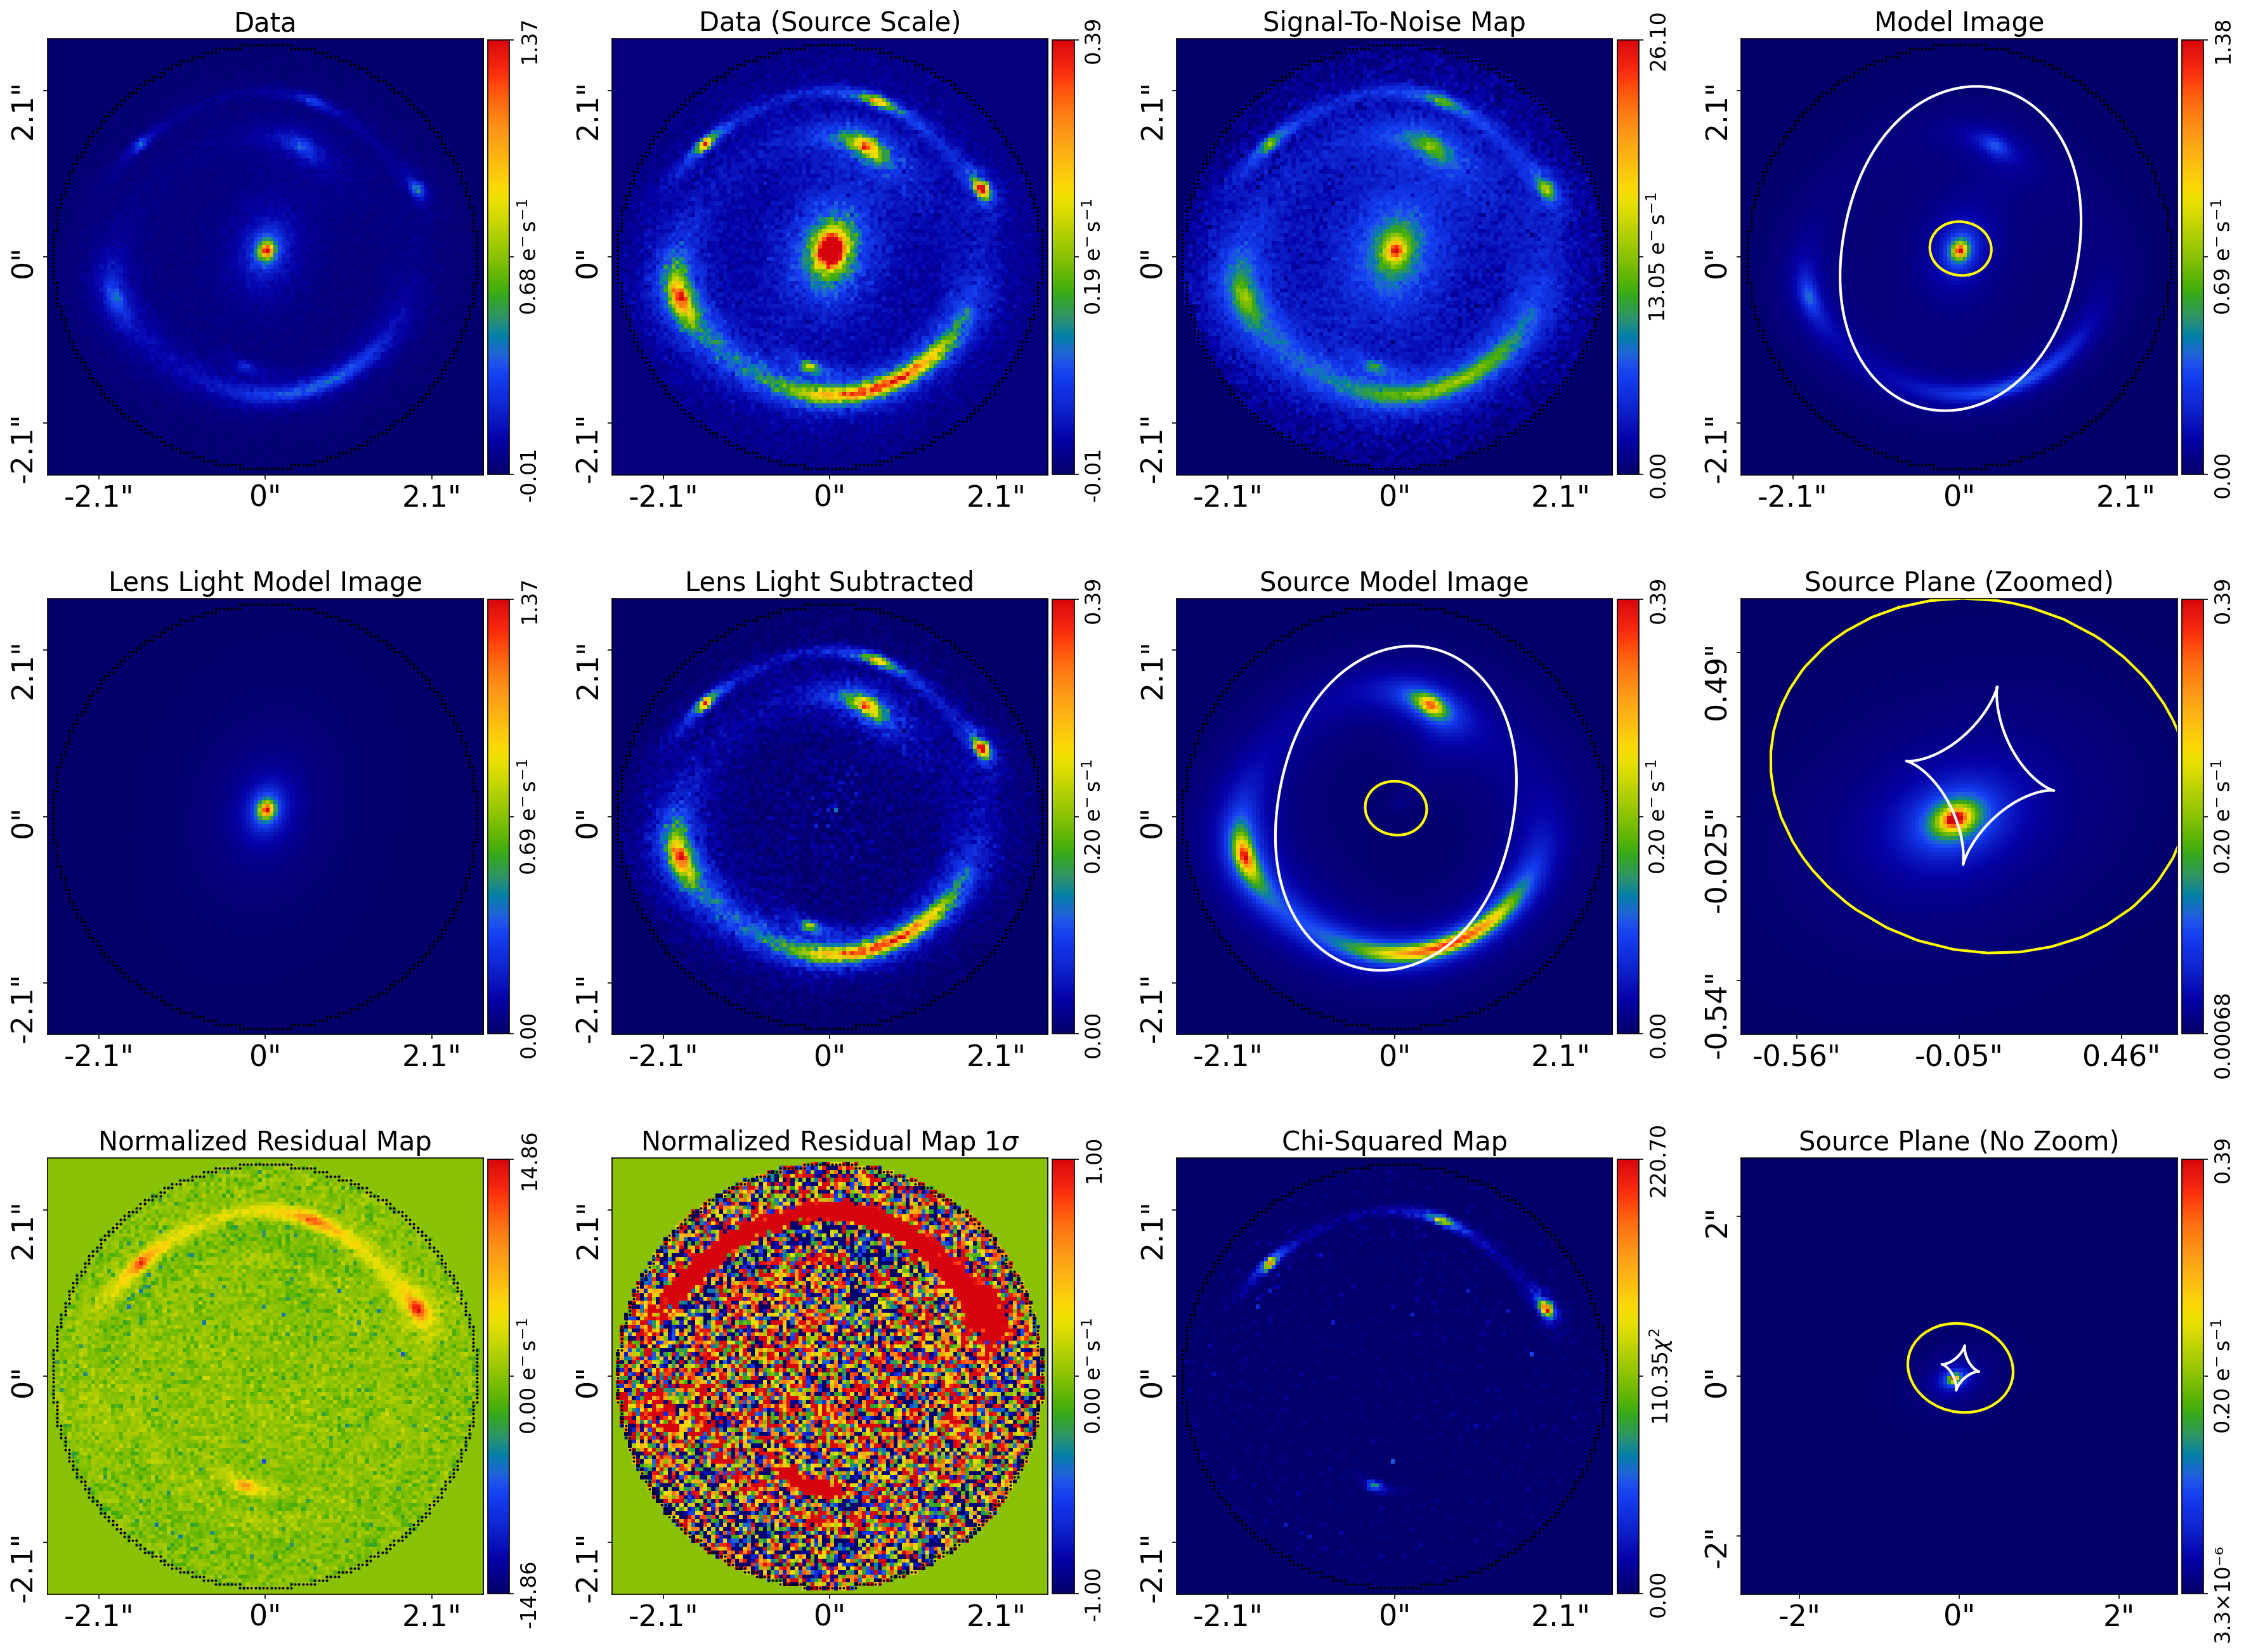

### mock_3

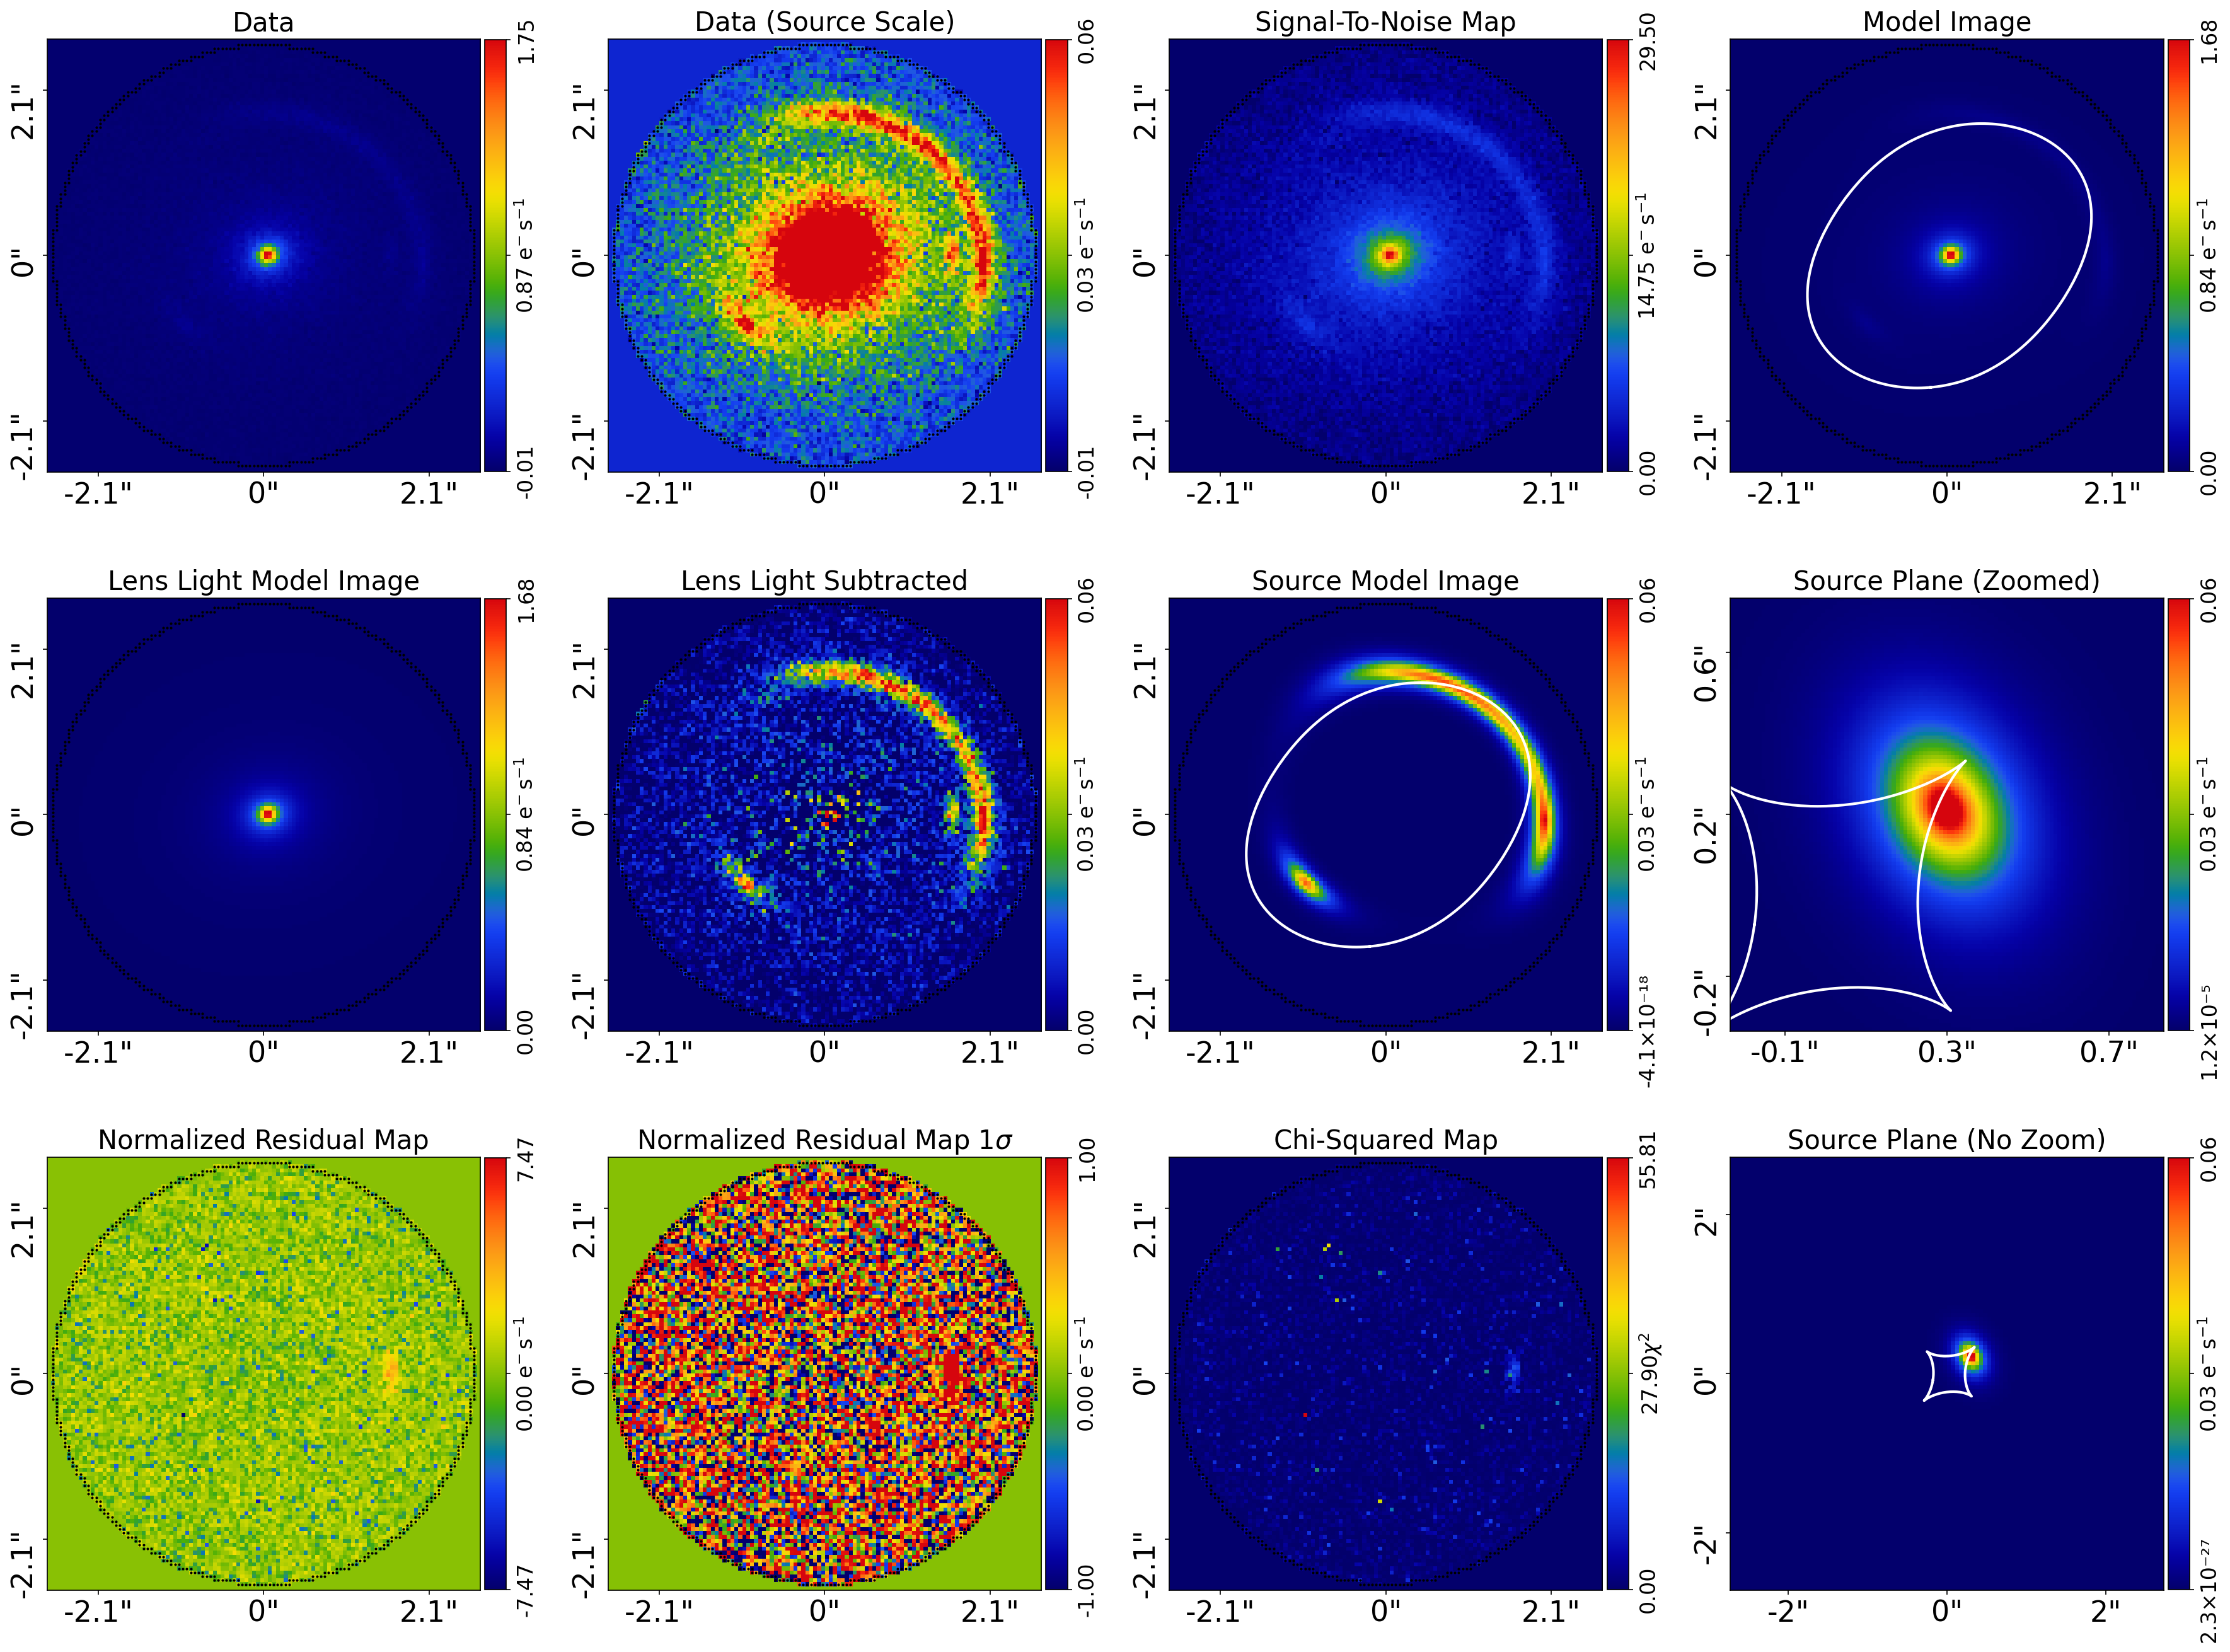

### mock_4

### mock_5

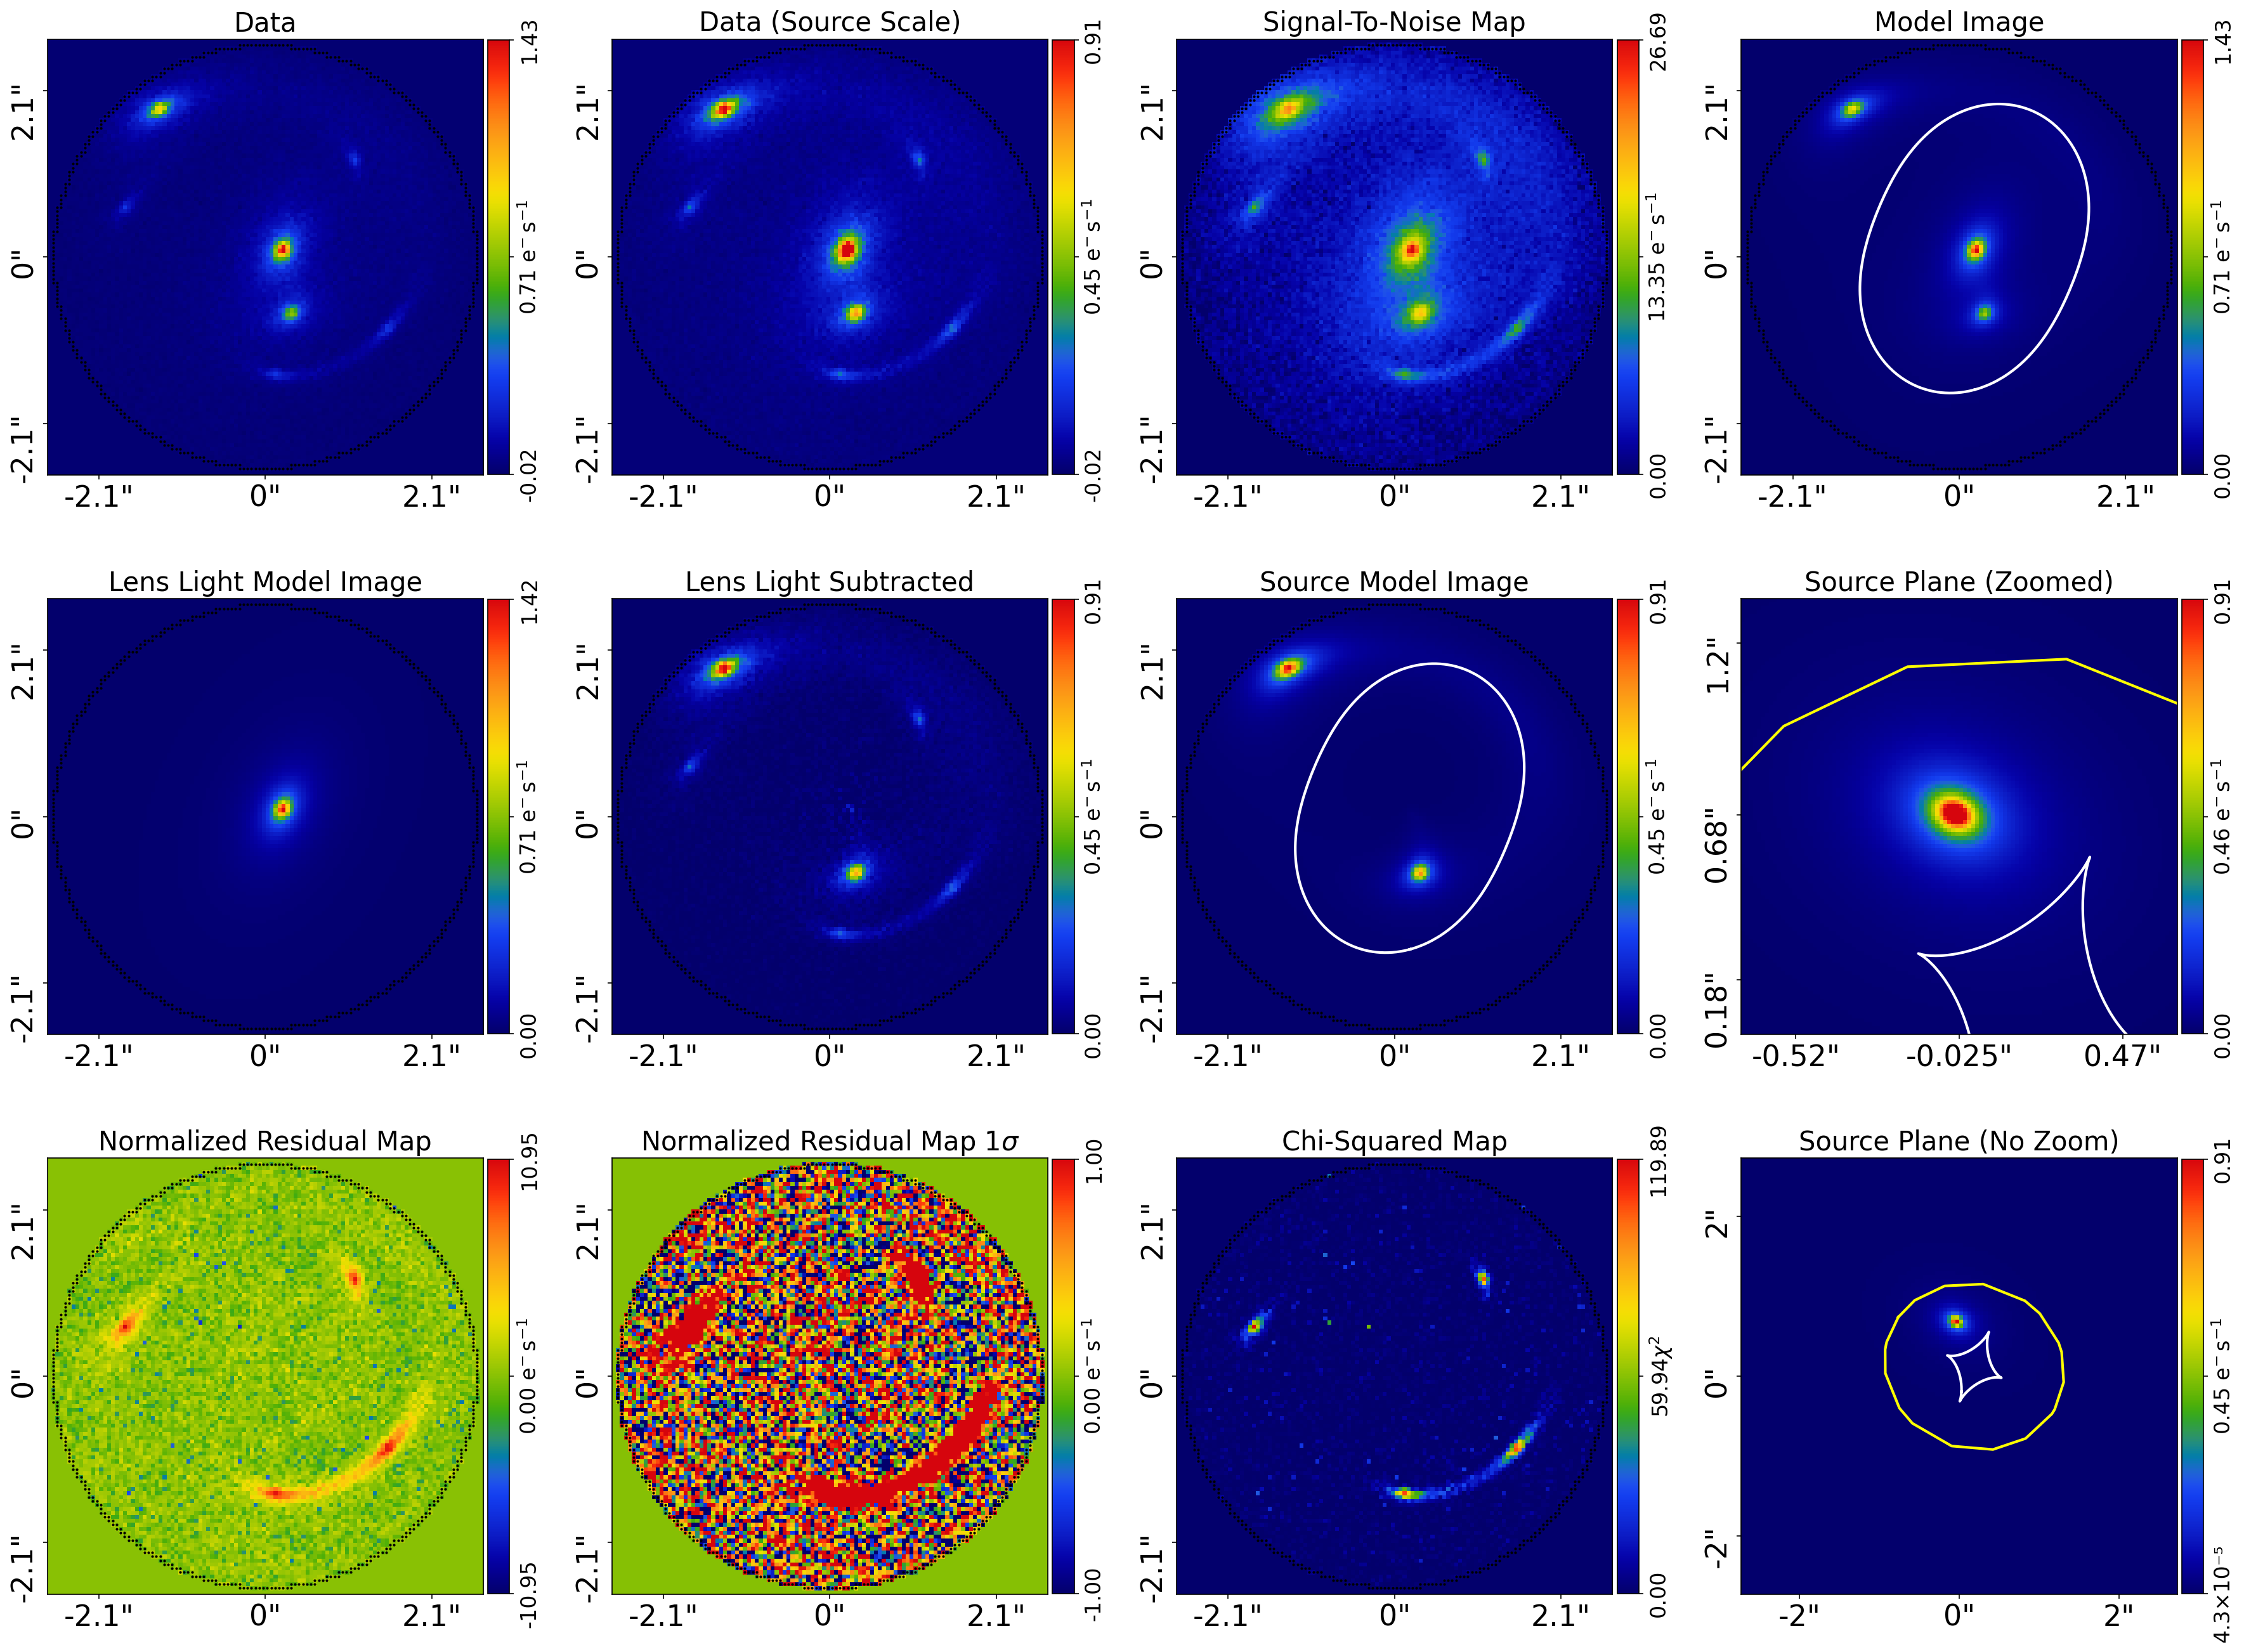

### mock_6

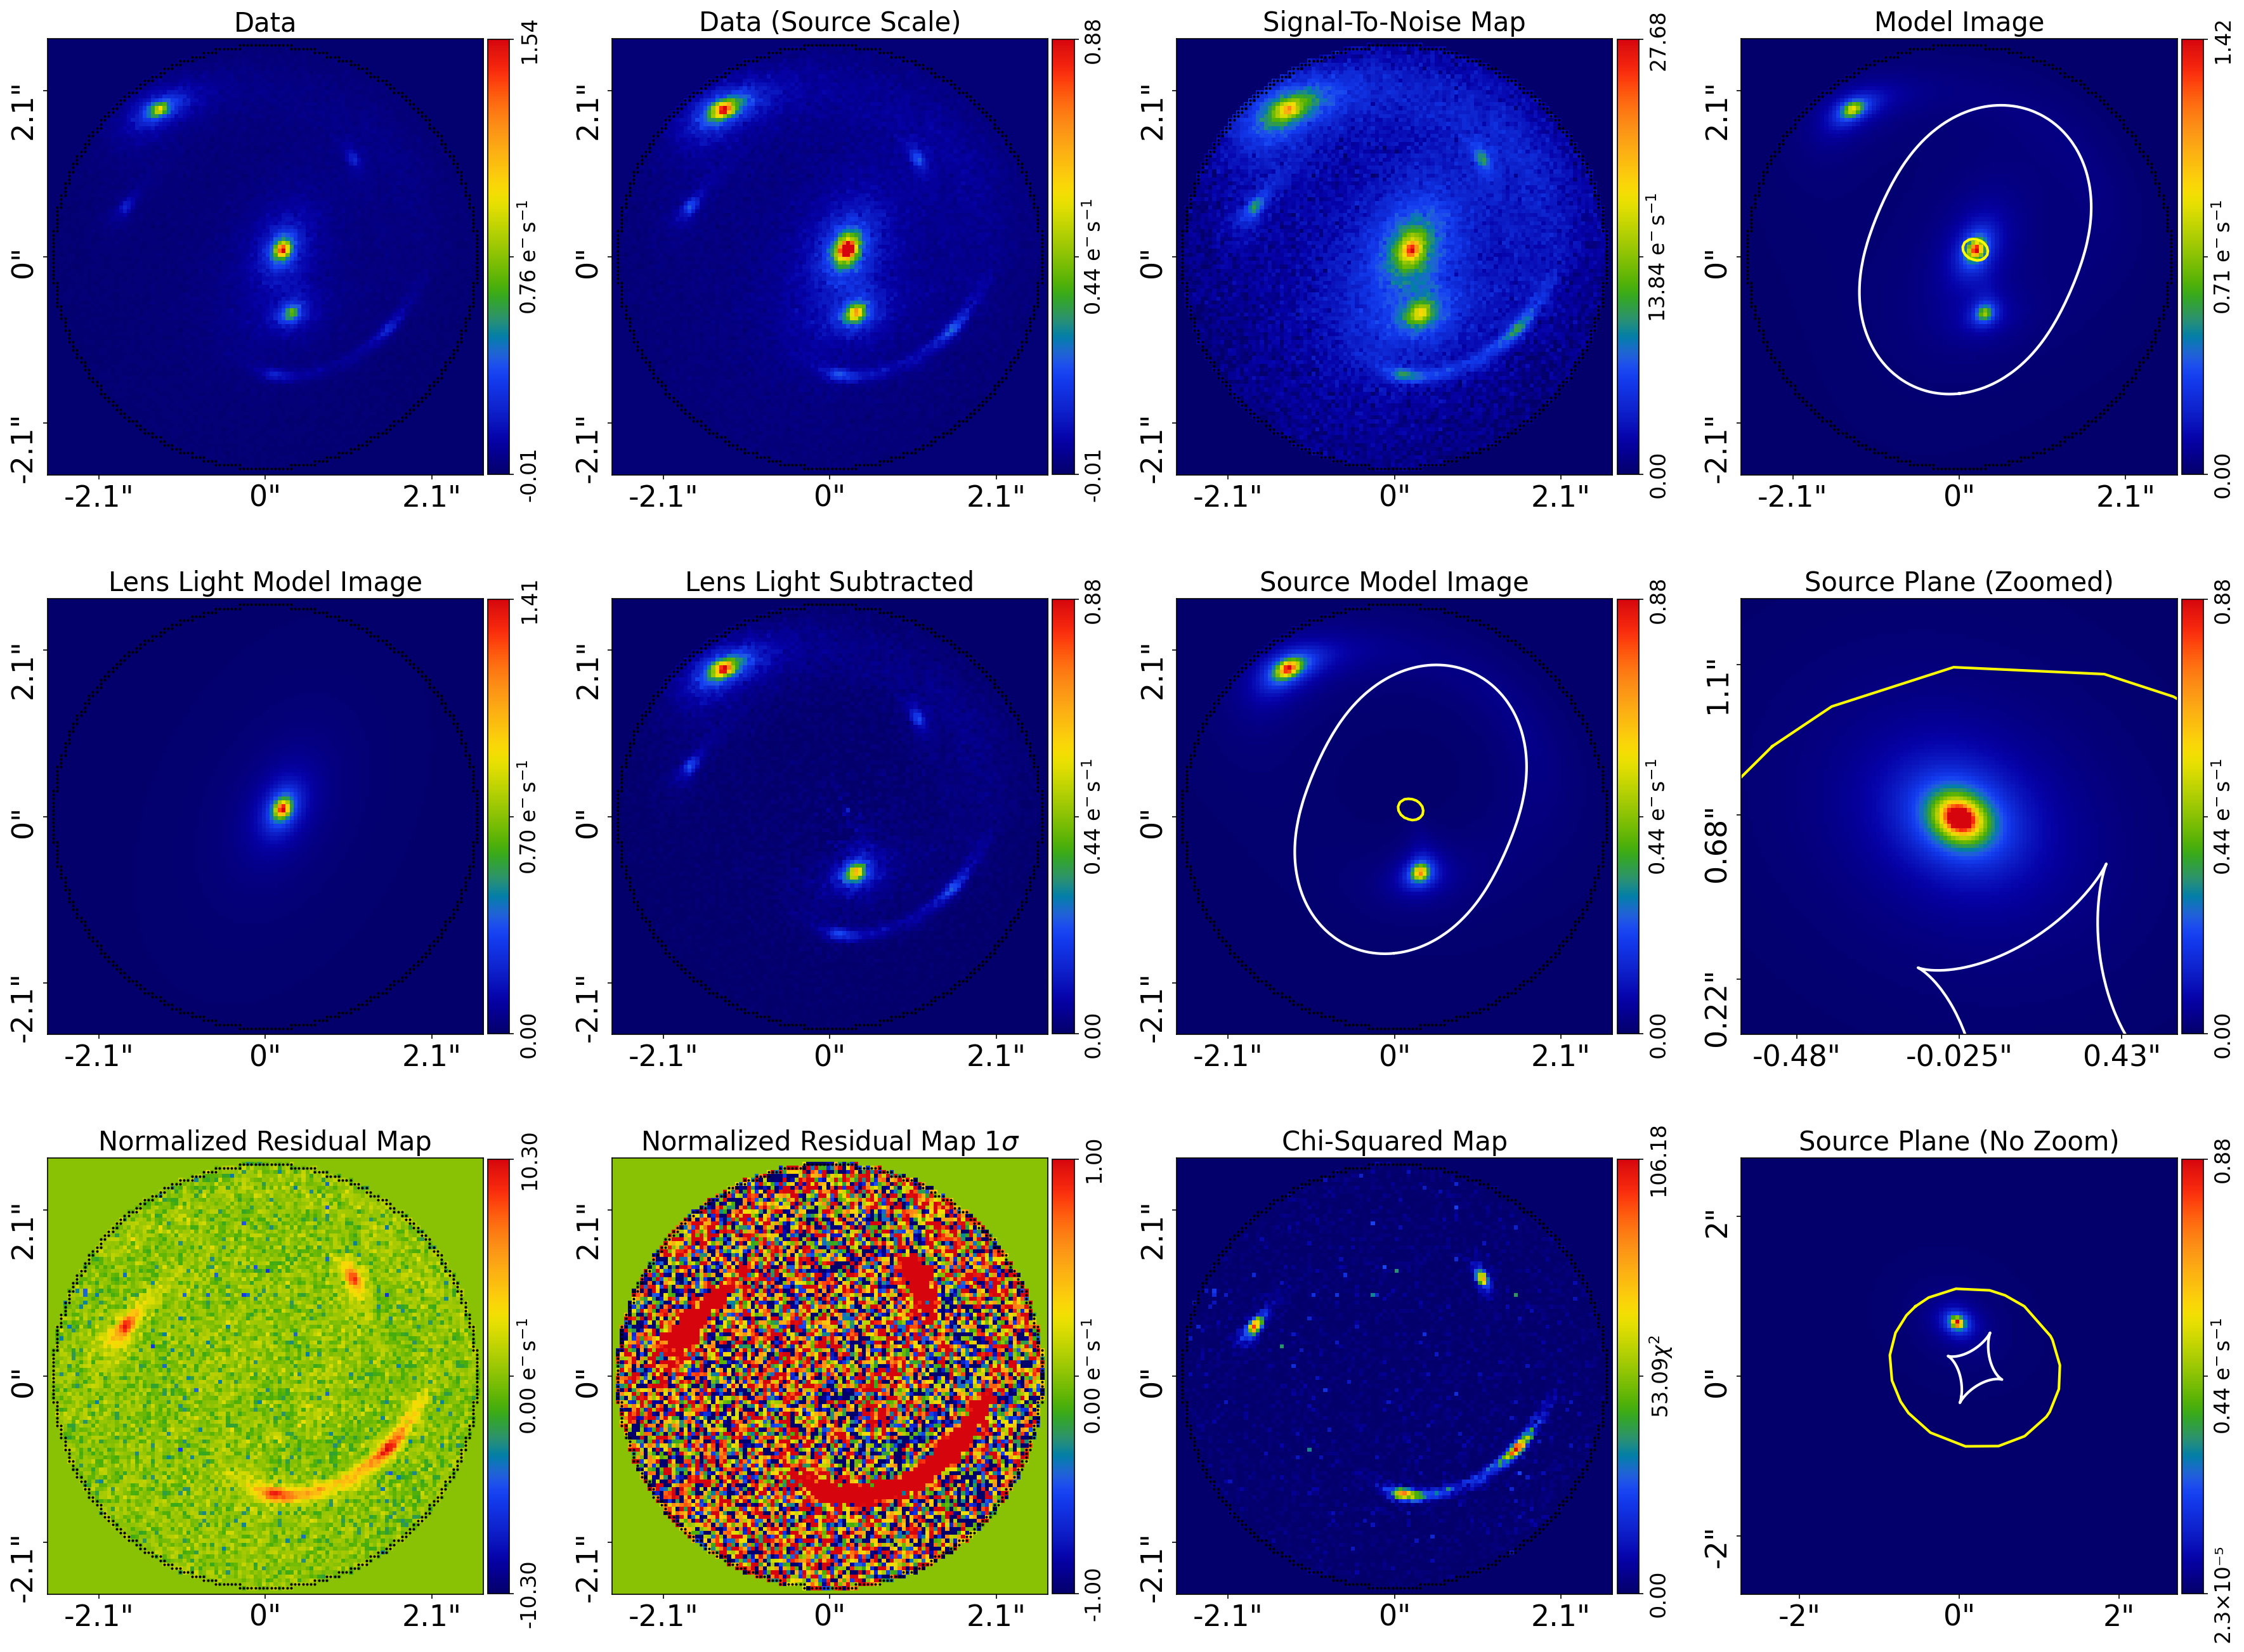

In [4]:
for n in MOCK_INDICES:
    fp = RESULTS_DIR / f"mock_{n}" / "fit_subplot.png"
    if fp.exists():
        display(Markdown(f"### mock_{n}"))
        display(Image(filename=str(fp)))
    else:
        display(Markdown(f"### mock_{n} — *(no Cannon result yet)*"))

---

## 4. Audit summary across the zoo

Apply the per-mock physical bar (chi²/N ≤ 1.3 PASS, ≤ 2.0 SUSPECT; max|res| ≤ 4σ PASS, ≤ 6σ SUSPECT). The pedagogical question is whether the *same* prior set passes all five mocks. If 4-of-5 pass and 1 fails, the failure is the data point — what specifically about the failed mock breaks the methodology?

*(Verdict pending Cannon results.)*

## 5. Cosmology mis-specification (mocks 2 and 5)

Mocks 2 and 5 were generated with non-standard cosmology (Ωₘ=0.25/w=−0.9 and Ωₘ=0.35/w=−1.2 respectively) but fit at the standard FlatLambdaCDM(70, 0.30). Compare the recovered γ′ and θ_E to truth — any systematic offsets quantify how cosmology mis-specification feeds into mass-profile inference. Exercise 2 in `README.md` explicitly compares fit-at-truth-cosmology vs fit-at-standard-cosmology to make this clean.

---

*Learning to Autolens — Examples / compound_lens_zoo / 01*  
*Rodrigo Córdova Rosado, Harvard CfA*